In [1]:
pip install pandas numpy matplotlib seaborn openpyxl

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

# קריאת קובץ אקסל
df = pd.read_excel(r"C:\Users\USER\Desktop\לימודים\פרויקט גמר ב\סיוג חשבונות באינסטגרם - מאמר מחקר 1 נועה\איחוד דאטה סט.xlsx")

# הצגת 5 שורות ראשונות
df.head()


,numberOfFollowers,numberOfFollowing,nums/length username,hasDigitsInUsername,hasProfilePicture,descriptionLength,isPrivate,numberOfPosts,Following/Followers,Following/Posts,Followers/Posts,isFake,usernameDigitCount,usernameLength
0,488,604,0.33,1,1,30,1,35,1.237705,17.257143,13.942857,0,NaN,NaN
1,35,6,0.00,0,1,64,1,3,0.171429,2.000000,11.666667,0,NaN,NaN
2,328,668,0.00,0,1,82,1,319,2.036585,2.094044,1.028213,0,NaN,NaN
3,14890,7369,0.00,0,1,143,1,273,0.494896,26.992674,54.542125,0,NaN,NaN
4,225,356,0.50,1,1,76,1,6,1.582222,59.333333,37.500000,0,NaN,NaN


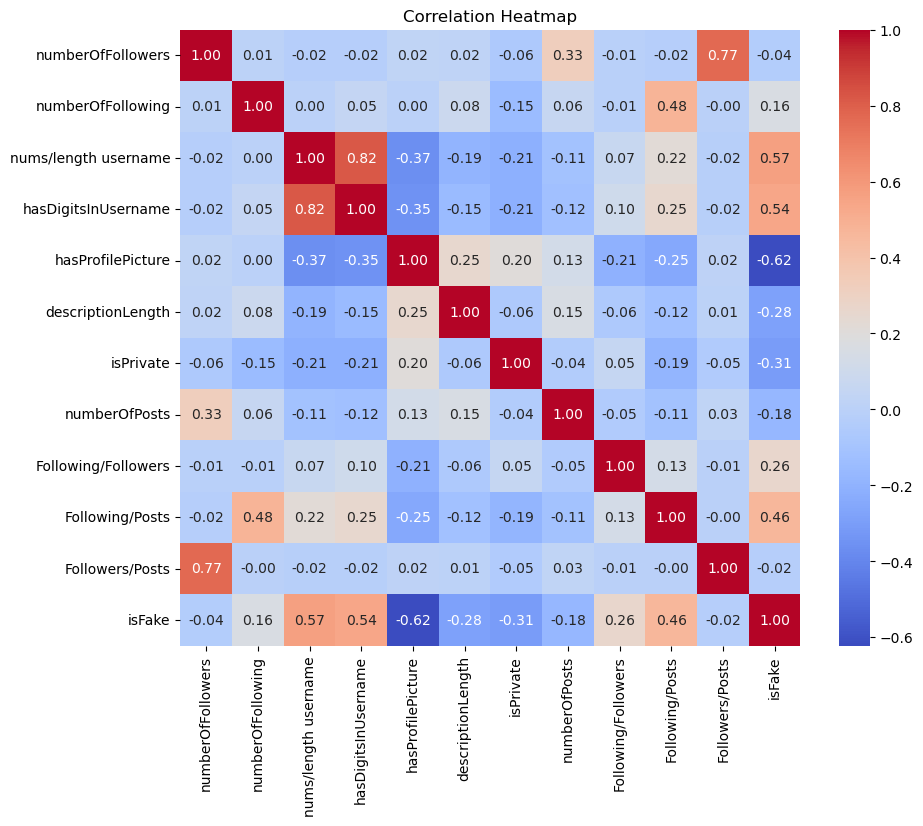

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df.corr()

correlation_matrix = correlation_matrix.drop(
    columns=["usernameDigitCount", "usernameLength"],
    index=["usernameDigitCount", "usernameLength"]
) 
plt.figure(figsize=(10, 8))

sns.heatmap(correlation_matrix, 
            annot=True,        # מציג מספרים בתוך התאים
            cmap='coolwarm',   # צבעים
            fmt=".2f")         # 2 ספרות אחרי הנקודה

plt.title("Correlation Heatmap")
plt.show()

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score,recall_score, f1_score, roc_auc_score


In [5]:
X = df.drop(columns=['isFake','usernameDigitCount','usernameLength'])
y = df['isFake']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

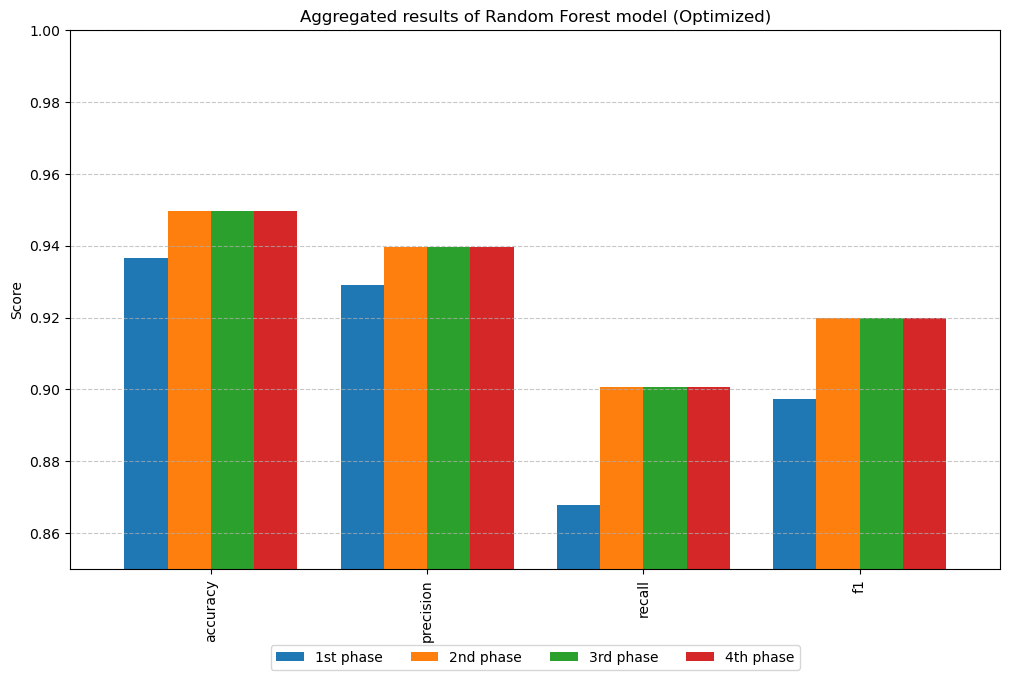

In [8]:
feature_sets = {
    "1st phase": X.drop(columns=['Following/Followers', 'Following/Posts', 'Followers/Posts']).columns.tolist(),
    "2nd phase": X.drop(columns=['Following/Posts', 'Followers/Posts']).columns.tolist(),
    "3rd phase": X.drop(columns=['Followers/Posts']).columns.tolist(),
    "4th phase": X.columns.tolist()
}

rf_params = {
    'n_estimators': 100,
    'max_depth': 10,
    'min_samples_split': 5,
    'random_state': 42,
    'n_jobs': -1
}

all_metrics = []

for name, features in feature_sets.items():

    X_train_sub = X_train[features]
    X_test_sub = X_test[features]

    model = RandomForestClassifier(**rf_params)

    model.fit(X_train_sub, y_train)

    y_pred = model.predict(X_test_sub)

    metrics = {
        "Phase": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
    }

    all_metrics.append(metrics)

# יצירת DataFrame
results_df = pd.DataFrame(all_metrics)

# הגדרת האינדקס
results_df = results_df.set_index("Phase")

# גרף
results_df.T.plot(kind='bar', figsize=(12, 7), width=0.8)

plt.title("Aggregated results of Random Forest model (Optimized)")
plt.ylabel("Score")
plt.ylim(0.85, 1.0)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, -0.2),
    ncol=4
)

plt.show()


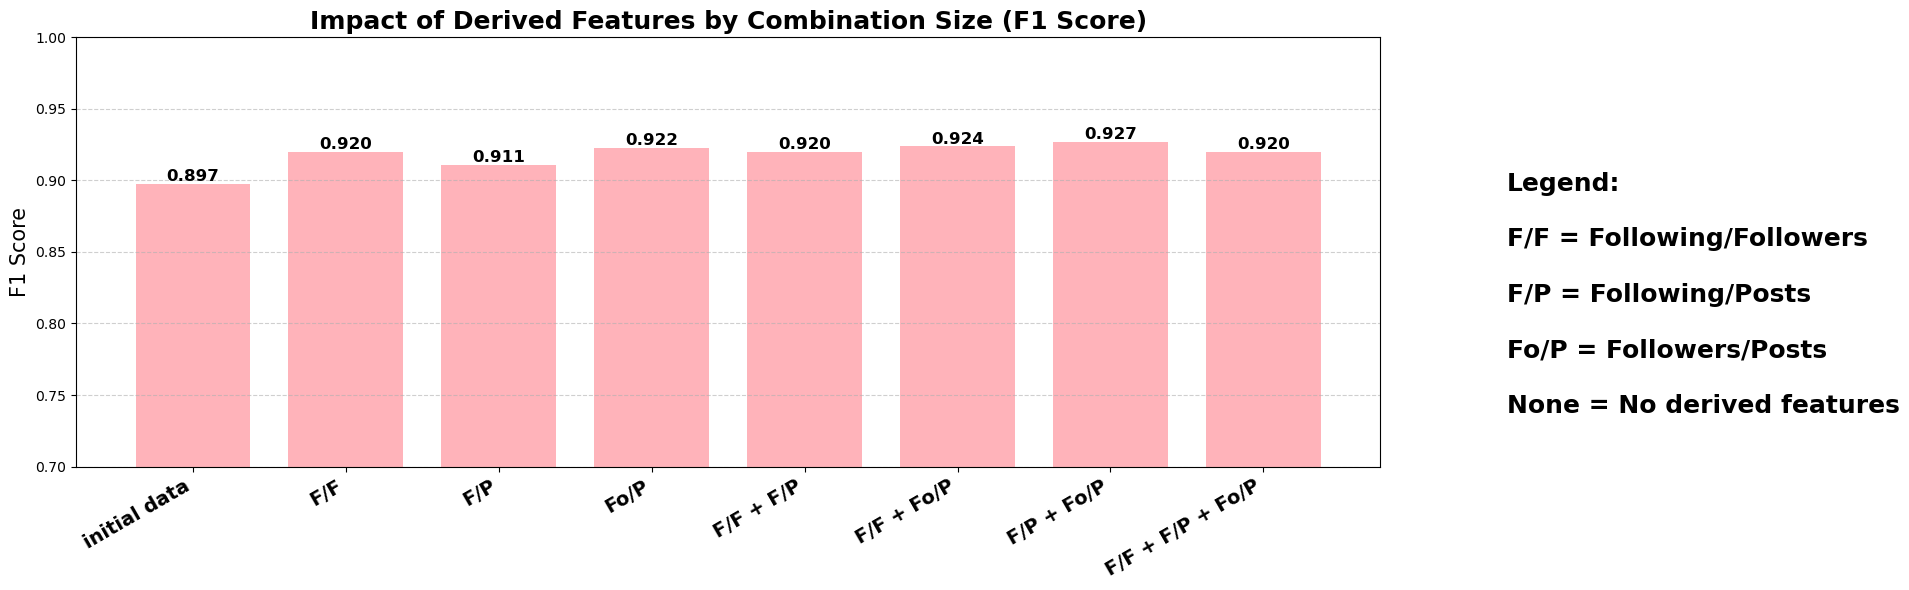

🏆 BEST MODEL SUMMARY 🏆
Best Combination : F/P + Fo/P
Best F1 Score    : 0.9270
Number of Features: 10

Selected Features:
  1. numberOfFollowers
  2. numberOfFollowing
  3. nums/length username
  4. hasDigitsInUsername
  5. hasProfilePicture
  6. descriptionLength
  7. isPrivate
  8. numberOfPosts
  9. Following/Posts
  10. Followers/Posts


In [10]:
import itertools
import matplotlib.pyplot as plt
import pandas as pd

derived_features = ['Following/Followers', 'Following/Posts', 'Followers/Posts']

results = []

best_model = None # האובייקט של המודל הטוב ביותר
best_f1 = 0 # ציון הכי גבוה שנמצא עד כה
best_features = None #אילו פיצ'רים נכללו במודל הטוב ביותר
best_combo_name = ''

def short_name(combo):
  mapping = {
      'Following/Followers': 'F/F',
      'Following/Posts': 'F/P',
      'Followers/Posts': 'Fo/P',
  }
  return ' + '.join([mapping[c] for c in combo]) if combo else 'initial data'


for r in range(len(derived_features) + 1): #כמה פיצ'רים יכללו בכל שילוב 
  for combo in itertools.combinations(derived_features, r):#יצירה של כל הצירופים האפשריים ללא חשיבות לסדר

    drop_cols = [f for f in derived_features if f not in combo]
    features = X.drop(columns=drop_cols).columns.tolist()

    X_train_sub = X_train[features]
    X_test_sub = X_test[features]

    model = RandomForestClassifier(**rf_params)
    model.fit(X_train_sub, y_train)

    y_pred = model.predict(X_test_sub)
    f1 = f1_score(y_test, y_pred)

    # בדיקה אם זה המודל הכי טוב
    if f1 > best_f1:
      best_f1 = f1
      best_model = model
      best_features = features
      best_combo_name = short_name(combo)

    results.append(
        {'Combination': short_name(combo), 'F1': f1, 'num_features': r}
    )

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='num_features')
#כלל החלק מטה מציג את התוצאות של השילובים של התכונות על הביצועים של המודל
plt.figure(figsize=(14, 6))

bars = plt.bar(
    results_df['Combination'],
    results_df['F1'],
    width=0.75,
    color='#FFB3BA',
)

plt.title(
    'Impact of Derived Features by Combination Size (F1 Score)',
    fontsize=18,
    fontweight='bold',
)

plt.ylabel('F1 Score', fontsize=15)
plt.ylim(0.7, 1)

plt.xticks(rotation=30, ha='right', fontsize=14, fontweight='bold')

for bar in bars:
  yval = bar.get_height()
  plt.text(
      bar.get_x() + bar.get_width() / 2,
      yval + 0.002,
      f'{yval:.3f}',
      ha='center',
      fontsize=12,
      fontweight='bold',
  )

legend_text = (
    'Legend:\n\n'
    'F/F = Following/Followers\n\n'
    'F/P = Following/Posts\n\n'
    'Fo/P = Followers/Posts\n\n'
    'None = No derived features'
)

plt.gcf().text(
    1.08, 0.5, legend_text, fontsize=18, va='center', fontweight='bold'
)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig(
    'derived_features_f1_high_quality.png', dpi=300, bbox_inches='tight'
)
plt.show()

# ⭐ הדפסת סיכום המודל הטוב ביותר
print('=' * 50)
print('🏆 BEST MODEL SUMMARY 🏆')
print('=' * 50)
print(f'Best Combination : {best_combo_name}')
print(f'Best F1 Score    : {best_f1:.4f}')
print(f'Number of Features: {len(best_features)}')
print('\nSelected Features:')
for i, feat in enumerate(best_features, 1):
  print(f'  {i}. {feat}')
print('=' * 50)

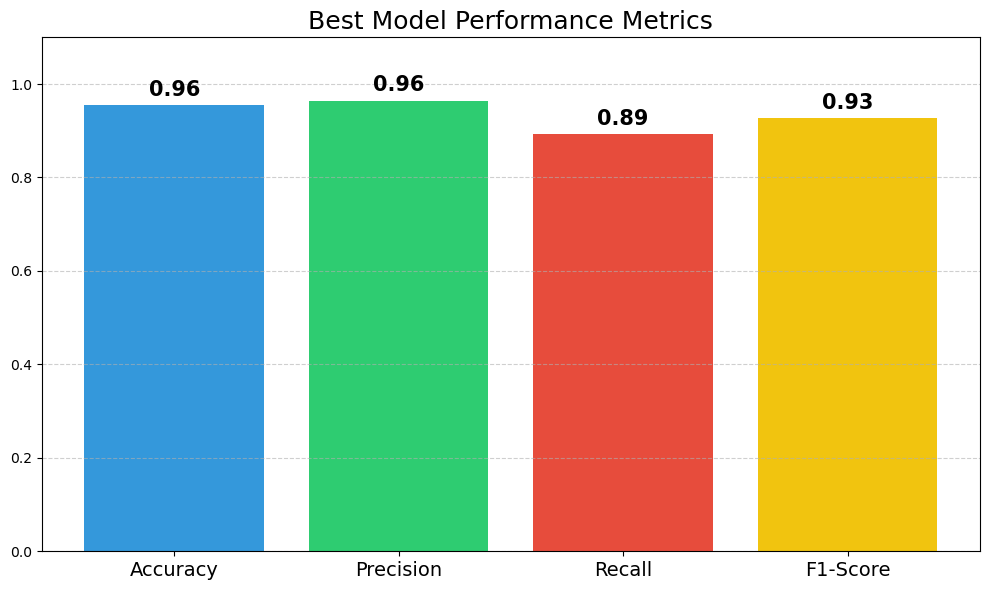

In [15]:
# שימוש רק בפיצ'רים של המודל הכי טוב
X_test_best = X_test[best_features]

# חיזוי
y_pred = best_model.predict(X_test_best)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# ויזואליזציה
metrics_names = ['accuracy', 'precision', 'recall', 'f1']
values = [acc, prec, rec, f1]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f1c40f']

plt.figure(figsize=(10,6))

bars = plt.bar(
    ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    values,
    color=colors,
    edgecolor='none'
)

plt.title("Best Model Performance Metrics", fontsize=18)
plt.ylim(0, 1.1)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.02,
        f"{yval:.2f}",
        ha='center',
        fontsize=15,
        fontweight='bold'
    )

plt.xticks(fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [17]:
def predict_instagram_interactive_full(model, feature_columns):
    print("Instagram Fake Account Detector ---\n")

    num_followers = float(input("Number of followers: "))
    num_following = float(input("Number of following: "))
    num_posts = float(input("Number of posts: "))
    digit_in_username = float(input("Number of digits in username: "))
    username_length = float(input("Username length: "))
    has_profile_pic_raw = input("Has profile picture? (yes/no): ").strip().lower()
    is_private_raw = input("Is the account private? (yes/no): ").strip().lower()
    description_length = float(input("Bio length (characters): "))

    nums_length_ratio = digit_in_username / username_length if username_length else 0
    has_digit_in_username = 1 if digit_in_username > 0 else 0
    has_profile_pic = 1 if has_profile_pic_raw == "yes" else 0
    is_private = 1 if is_private_raw == "yes" else 0

    following_posts_ratio = num_following / num_posts if num_posts else 0.0
    followers_posts_ratio = num_followers / num_posts if num_posts else 0.0

    # כל הפיצ'רים האפשריים- יצירת מילון
    user_features = {
        'numberOfFollowers': num_followers,
        'numberOfFollowing': num_following,
        'nums/length username': nums_length_ratio,
        'hasDigitsInUsername': has_digit_in_username,
        'hasProfilePicture': has_profile_pic,
        'descriptionLength': description_length,
        'isPrivate': is_private,
        'numberOfPosts': num_posts,
        'Following/Posts': following_posts_ratio,
        'Followers/Posts': followers_posts_ratio
    }

    # יצירת DataFrame
    input_df = pd.DataFrame([user_features])

    # שמירה רק על הפיצ'רים שהמודל צריך
    input_df = input_df[feature_columns]

    prediction = model.predict(input_df)[0] #בקשה מהמודל סיווג, זה תמיד מחזיר מערך 
    probabilities = model.predict_proba(input_df)[0]

    for cls, prob in zip(model.classes_, probabilities):
        print(f"Class {cls}: {prob*100:.2f}%")

    confidence = probabilities[prediction] * 100
    label = "FAKE" if prediction == 1 else "REAL"

    print("\n==============================")
    print(f"Prediction Result: {label}")
    print(f"Confidence Level: {confidence:.2f}%")
    print("==============================")

    return prediction, confidence
prediction, confidence = predict_instagram_interactive_full(
    best_model,
    best_features   
)

Instagram Fake Account Detector ---



Number of followers:  9
Number of following:  113
Number of posts:  12
Number of digits in username:  7
Username length:  18
Has profile picture? (yes/no):  yes
Is the account private? (yes/no):  yes
Bio length (characters):  40


Class 0: 20.11%
Class 1: 79.89%

Prediction Result: FAKE
Confidence Level: 79.89%
